In [1]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPUs detected:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.10.1
GPUs detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import tensorflow as tf
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np

In [3]:
img_array = cv2.imread("train/angry/Training_3908.jpg")

In [4]:
img_array.shape

(48, 48, 3)

In [5]:
print(img_array)

[[[163 163 163]
  [128 128 128]
  [114 114 114]
  ...
  [139 139 139]
  [141 141 141]
  [134 134 134]]

 [[147 147 147]
  [114 114 114]
  [102 102 102]
  ...
  [142 142 142]
  [138 138 138]
  [138 138 138]]

 [[112 112 112]
  [106 106 106]
  [ 92  92  92]
  ...
  [140 140 140]
  [141 141 141]
  [134 134 134]]

 ...

 [[139 139 139]
  [141 141 141]
  [136 136 136]
  ...
  [154 154 154]
  [171 171 171]
  [191 191 191]]

 [[140 140 140]
  [133 133 133]
  [120 120 120]
  ...
  [138 138 138]
  [146 146 146]
  [158 158 158]]

 [[136 136 136]
  [134 134 134]
  [113 113 113]
  ...
  [146 146 146]
  [144 144 144]
  [144 144 144]]]


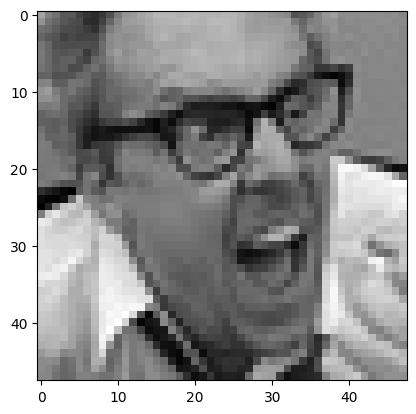

In [6]:
plt.imshow(img_array)

In [7]:
Datadirectory = "train/"

In [8]:
Classes = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]

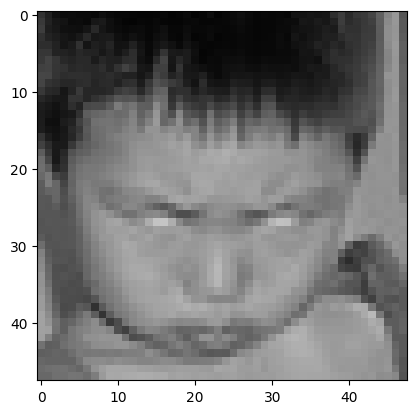

In [9]:
for category in Classes:
    path = os.path.join(Datadirectory, category)
    for img in os.listdir(path):
        img_array = cv2.imread(os.path.join(path,img))
        plt.imshow(cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB))
        plt.show()
        break
    break

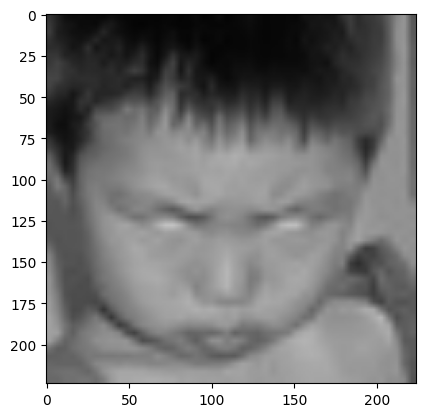

In [10]:
img_size=224
new_array=cv2.resize(img_array, (img_size,img_size))
plt.imshow(cv2.cvtColor(new_array, cv2.COLOR_BGR2RGB))
plt.show()

In [11]:
new_array.shape

(224, 224, 3)

In [12]:
training_Data = []

def create_training_Data():
    for category in Classes:
        path = os.path.join(Datadirectory, category)
        class_num = Classes.index(category)
        for img in os.listdir(path):
            try:
                img_array = cv2.imread(os.path.join(path,img))
                new_array = cv2.resize(img_array, (img_size,img_size))
                training_Data.append([new_array, class_num])
            except Exception as e:
                pass

In [13]:
create_training_Data()

In [14]:
print(len(training_Data))

28709


In [15]:
import random
random.shuffle(training_Data)

In [16]:
X = []
y = []

for features,label in training_Data:
    X.append(features)
    y.append(label)
    
X = np.array(X).reshape(-1, img_size, img_size, 3)

In [17]:
X.shape

(28709, 224, 224, 3)

In [18]:
X = X/255.0;

In [19]:
y[0]

4

In [20]:
type(y)

list

In [21]:
Y = np.array(y)

In [22]:
Y.shape

(28709,)

In [23]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [24]:
model = tf.keras.applications.MobileNetV2() 

In [25]:
model.summary()

Model: "mobilenetv2_1.00_224"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 Conv1 (Conv2D)                 (None, 112, 112, 32  864         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, 112, 112, 32  128         ['Conv1[0][0]']                  
                                )                                              

In [26]:
base_input = model.layers[0].input

In [27]:
base_output = model.layers[-2].output

In [28]:
base_output

<KerasTensor: shape=(None, 1280) dtype=float32 (created by layer 'global_average_pooling2d')>

In [29]:
final_output = layers.Dense(128)(base_output)
final_output - layers.Activation('relu')(final_output)

<KerasTensor: shape=(None, 128) dtype=float32 (created by layer 'tf.math.subtract')>

In [30]:
final_output = layers.Dense(128)(base_output)
final_output = layers.Activation('relu')(final_output)

In [31]:
final_output = layers.Dense(128)(base_output)
final_output = layers.Activation('relu')(final_output)
final_output = layers.Dense(64)(final_output)
final_output = layers.Activation('relu')(final_output)
final_output = layers.Dense(7,activation = 'softmax')(final_output)

In [32]:
final_output

<KerasTensor: shape=(None, 7) dtype=float32 (created by layer 'dense_4')>

In [33]:
new_model = keras.Model(inputs = base_input, outputs = final_output)

In [34]:
new_model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 Conv1 (Conv2D)                 (None, 112, 112, 32  864         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, 112, 112, 32  128         ['Conv1[0][0]']                  
                                )                                                             

In [35]:
new_model.compile(loss="sparse_categorical_crossentropy", optimizer = "adam", metrics = ["accuracy"])

In [36]:
physical_devices = tf.config.list_physical_devices('GPU')
print(f"Number of GPUs available: {len(physical_devices)}")


Number of GPUs available: 1


In [37]:
training_Data = []
def create_training_Data():
    count = 0
    for category in Classes:
        path = os.path.join(Datadirectory, category)
        class_num = Classes.index(category)
        for img in os.listdir(path):
            if count >= 50:  # Limit the dataset to 50 images for testing
                break
            try:
                img_array = cv2.imread(os.path.join(path, img))
                new_array = cv2.resize(img_array, (img_size, img_size))
                training_Data.append([new_array, class_num])
                count += 1
            except Exception as e:
                pass
create_training_Data()
print(len(training_Data))


50


In [38]:
tf.config.set_visible_devices([], 'GPU')  # Disable GPU and force CPU usage

RuntimeError: Visible devices cannot be modified after being initialized

In [39]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

# Path to your training dataset
train_directory = "train/"
img_size = 224
batch_size = 32

# Create the data generator
train_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    directory=train_directory,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='sparse',  # because labels are integers 0–6
    shuffle=True
)


Found 28709 images belonging to 7 classes.


In [40]:
# Load base model
base_model = MobileNetV2(include_top=False, input_shape=(img_size, img_size, 3), pooling='avg', weights='imagenet')
base_model.trainable = False  # Freeze base model initially

# Add custom layers on top
x = layers.Dense(128, activation='relu')(base_model.output)
x = layers.Dense(64, activation='relu')(x)
output = layers.Dense(7, activation='softmax')(x)

# Final model
new_model = models.Model(inputs=base_model.input, outputs=output)
new_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
new_model.summary()


9406464/9406464 [==============================] - 0s 0us/step
Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 Conv1 (Conv2D)                 (None, 112, 112, 32  864         ['input_2[0][0]']                
                                )                                                                 
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, 112, 112, 32  128         ['Conv1[0][0]']                  
                             

In [41]:
# Train using generator
history = new_model.fit(
    train_generator,
    epochs=25
)


Epoch 1/25
898/898 [==============================] - 235s 247ms/step - loss: 1.5217 - accuracy: 0.4122
Epoch 2/25
898/898 [==============================] - 43s 48ms/step - loss: 1.3844 - accuracy: 0.4687
Epoch 3/25
898/898 [==============================] - 43s 48ms/step - loss: 1.3343 - accuracy: 0.4897
Epoch 4/25
898/898 [==============================] - 43s 48ms/step - loss: 1.2931 - accuracy: 0.5066
Epoch 5/25
898/898 [==============================] - 43s 48ms/step - loss: 1.2629 - accuracy: 0.5206
Epoch 6/25
898/898 [==============================] - 44s 49ms/step - loss: 1.2291 - accuracy: 0.5339
Epoch 7/25
898/898 [==============================] - 43s 48ms/step - loss: 1.2043 - accuracy: 0.5432
Epoch 8/25
898/898 [==============================] - 43s 48ms/step - loss: 1.1758 - accuracy: 0.5544
Epoch 9/25
898/898 [==============================] - 43s 48ms/step - loss: 1.1540 - accuracy: 0.5636
Epoch 10/25
898/898 [==============================] - 43s 48ms/step - loss: 1.1

In [42]:
new_model.save("emotion_model.h5")  # You can change the name if you want

In [43]:
from tensorflow.keras.models import load_model

model = load_model("emotion_model.h5")

In [44]:
frame = cv2.imread("happyboy.jpg")

In [45]:
frame.shape

(200, 357, 3)

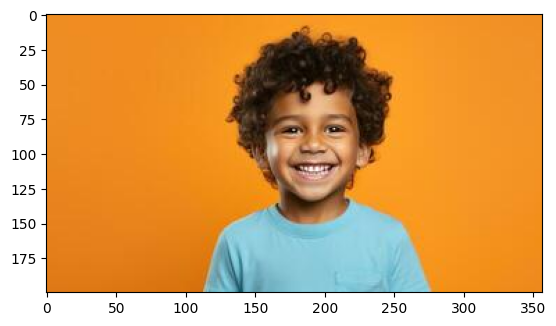

In [46]:
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

In [47]:
 faceCascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

In [48]:
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

In [49]:
gray.shape

(200, 357)

In [50]:
faces = faceCascade.detectMultiScale(gray,1.1,4)

In [54]:
faces = faceCascade.detectMultiScale(gray,1.1,4)
for x,y,w,h in faces:
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = frame[y:y+h, x:x+w]
    cv2.rectangle(frame, (x,y), (x+w, y+h), (255,0,0),2)
    facess = faceCascade.detectMultiScale(roi_gray)
    if len(facess) == 0:
        print("Face not detected")
    else:
        for (ex,ey,ew,eh) in facess:
            face_roi = roi_color[ey: ey+eh, ex:ex+ew]

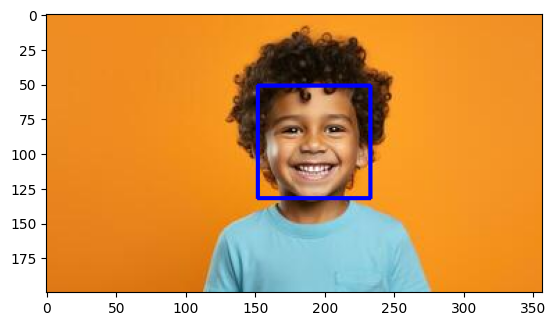

In [55]:
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

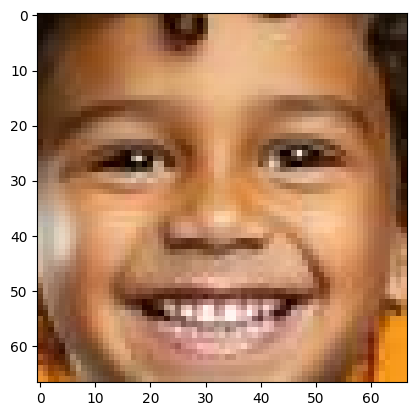

In [56]:
plt.imshow(cv2.cvtColor(face_roi, cv2.COLOR_BGR2RGB))

In [57]:
final_image = cv2.resize(face_roi, (224, 224))
final_image = np.expand_dims(final_image,axis  = 0)
final_image = final_image/255.0

In [58]:
Predictions = new_model.predict(final_image)

1/1 [==============================] - 1s 723ms/step


In [59]:
Predictions[0]

array([1.3755173e-04, 4.2346183e-13, 1.8437109e-10, 9.9986219e-01,
       5.8657810e-12, 2.9146526e-07, 2.3819045e-15], dtype=float32)

In [60]:
np.argmax(Predictions)

3

In [62]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

# Load your trained model
model = load_model("emotion_model.h5")

# Define class labels
class_names = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

# Initialize webcam
cap = cv2.VideoCapture(0)  # 0 for default webcam

# Load Haar Cascade for face detection
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

img_size = 224  # Make sure this matches your model input size

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Convert to grayscale (for face detection)
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Detect faces in frame
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    for (x, y, w, h) in faces:
        # Draw rectangle around face
        cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)

        # Extract face region of interest (ROI)
        face_roi = frame[y:y+h, x:x+w]
        face_roi = cv2.resize(face_roi, (img_size, img_size))
        face_roi = face_roi / 255.0
        face_roi = np.expand_dims(face_roi, axis=0)

        # Predict emotion
        predictions = model.predict(face_roi)
        emotion_index = np.argmax(predictions)
        emotion_label = class_names[emotion_index]

        # Display emotion label
        cv2.putText(frame, emotion_label, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX,
                    0.9, (255, 255, 255), 2)

    # Show the frame
    cv2.imshow('Real-time Emotion Detection', frame)

    # Break loop with 'q'
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release and close windows
cap.release()
cv2.destroyAllWindows()


1/1 [==============================] - 0s 22ms/step


In [63]:
import datetime

# Inside your face loop
timestamp = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
log_line = f"{timestamp}, Face {emotion_index}, Emotion: {emotion_label}\n"
with open("emotion_log.txt", "a") as f:
    f.write(log_line)


In [64]:
# Get frame width & height
frame_width = int(cap.get(3))
frame_height = int(cap.get(4))

# Define VideoWriter to save output
out = cv2.VideoWriter('output_with_emotions.avi',
                      cv2.VideoWriter_fourcc(*'XVID'),
                      10, (frame_width, frame_height))


In [65]:
out.write(frame)  # Save the frame with overlay

In [66]:
out.release()  # Release video writer

In [67]:
confidence = np.max(predictions)
label = f"{emotion_label} ({confidence*100:.1f}%)"

cv2.putText(frame, label, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX,
            0.9, (255, 255, 255), 2)

array([[[18, 23, 22],
        [18, 23, 21],
        [18, 23, 20],
        ...,
        [24, 26, 26],
        [22, 25, 24],
        [22, 25, 24]],

       [[20, 22, 22],
        [20, 22, 22],
        [21, 23, 23],
        ...,
        [20, 25, 24],
        [20, 25, 24],
        [19, 24, 23]],

       [[19, 21, 21],
        [21, 22, 22],
        [22, 22, 22],
        ...,
        [20, 25, 24],
        [19, 24, 23],
        [19, 24, 23]],

       ...,

       [[17, 17, 17],
        [17, 17, 17],
        [17, 17, 17],
        ...,
        [16, 16, 16],
        [16, 16, 16],
        [16, 16, 16]],

       [[17, 17, 17],
        [17, 17, 17],
        [17, 17, 17],
        ...,
        [17, 18, 17],
        [16, 17, 15],
        [16, 17, 15]],

       [[17, 17, 17],
        [17, 17, 17],
        [17, 17, 17],
        ...,
        [16, 17, 15],
        [16, 17, 15],
        [16, 17, 15]]], dtype=uint8)

In [72]:
import os
os.makedirs("detected_faces", exist_ok=True)

In [73]:
face_filename = f"face_{emotion_label}_{timestamp.replace(':', '-')}.jpg"
cv2.imwrite(f"detected_faces/{face_filename}", face_roi[0]*255.0)

True